In [16]:
import pandas as pd

In [17]:
df = pd.read_excel("metrics.xlsx","Sheet1")
print(df)

    # threads  sorter dynamic -O3  distance dynamic -O3
0           1            0.150524              0.002572
1           1            0.154595              0.003066
2           1            0.160627              0.002052
3           2            0.079708              0.001758
4           2            0.087563              0.002273
5           2            0.080710              0.001753
6           4            0.068051              0.016953
7           4            0.057940              0.026980
8           4            0.060545              0.021180
9           6            0.055770              0.028372
10          6            0.055042              0.021486
11          6            0.067054              0.025172
12          8            0.070101              0.004161
13          8            0.063349              0.039402
14          8            0.081830              0.002020
15         10            0.064966              0.041076
16         10            0.095360              0

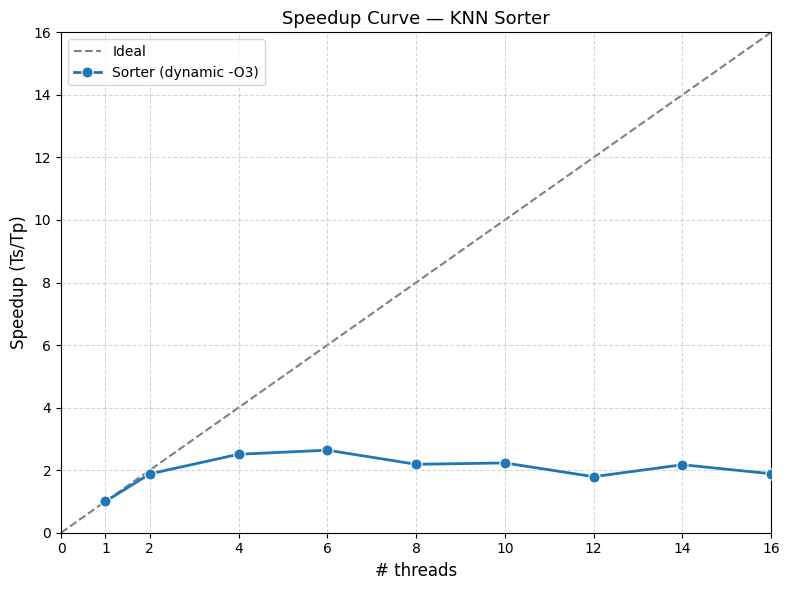

In [18]:
import matplotlib.pyplot as plt
import numpy as np

col = "sorter dynamic -O3"

Ts_val = df[df["# threads"] == 1][col].mean()
df_ac = df.copy()
df_ac[col] = Ts_val / df[col]

grouped = df_ac.groupby("# threads")[[col]]
ac_mean = grouped.mean().sort_index()
ac_std = grouped.std().sort_index()

threads = ac_mean.index.tolist()
max_t = threads[-1]
y = ac_mean[col].values

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([0, max_t], [0, max_t], linestyle="--", color="gray", linewidth=1.5, label="Ideal", zorder=1)

ax.plot(threads, y, marker="o", color="tab:blue", markersize=8,
        linewidth=2.0, markeredgecolor="white", markeredgewidth=0.8,
        label="Sorter (dynamic -O3)", zorder=3)

ax.set_xlabel("# threads", fontsize=12)
ax.set_ylabel("Speedup (Ts/Tp)", fontsize=12)
ax.set_title("Speedup Curve — KNN Sorter", fontsize=13)
ax.set_xticks([0] + threads)
ax.set_xlim(0, max_t)
ax.set_ylim(0, max_t)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


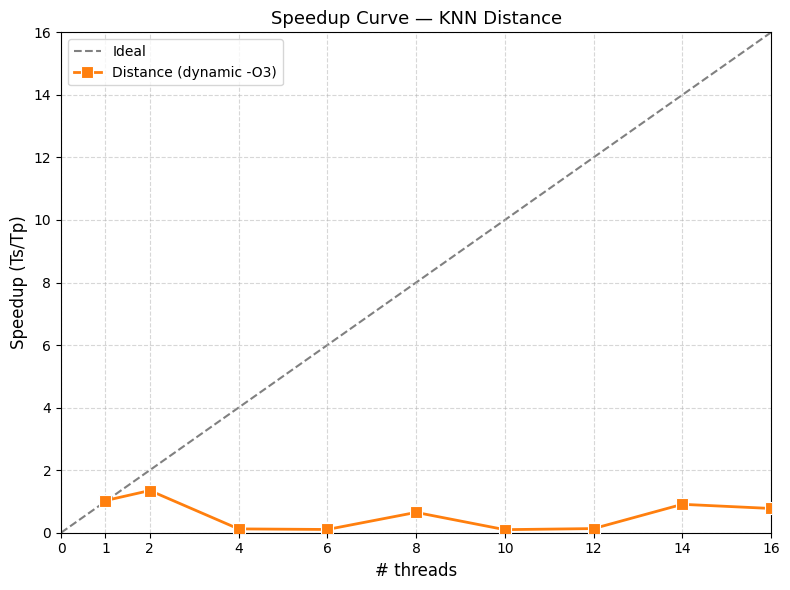

In [19]:
import matplotlib.pyplot as plt
import numpy as np

col = "distance dynamic -O3"

Ts_val = df[df["# threads"] == 1][col].mean()
df_ac = df.copy()
df_ac[col] = Ts_val / df[col]

grouped = df_ac.groupby("# threads")[[col]]
ac_mean = grouped.mean().sort_index()
ac_std = grouped.std().sort_index()

threads = ac_mean.index.tolist()
max_t = threads[-1]
y = ac_mean[col].values

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([0, max_t], [0, max_t], linestyle="--", color="gray", linewidth=1.5, label="Ideal", zorder=1)

ax.plot(threads, y, marker="s", color="tab:orange", markersize=8,
        linewidth=2.0, markeredgecolor="white", markeredgewidth=0.8,
        label="Distance (dynamic -O3)", zorder=3)

ax.set_xlabel("# threads", fontsize=12)
ax.set_ylabel("Speedup (Ts/Tp)", fontsize=12)
ax.set_title("Speedup Curve — KNN Distance", fontsize=13)
ax.set_xticks([0] + threads)
ax.set_xlim(0, max_t)
ax.set_ylim(0, max_t)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
